# Моделирование намерений в диалогах DialogSum-RU

Этот блокнот посвящён построению baseline-системы распознавания **намерений (intent) на уровне отдельных реплик** в русскоязычном датасете [`d0rj/dialogsum-ru`](https://huggingface.co/datasets/d0rj/dialogsum-ru).

## Контекст и предыдущие шаги

- В блокноте `07_dialogsum_ru_eda.ipynb` выполнен разведочный анализ датасета: распределения длин диалогов, частот тем (`topic`), статистика по сплитам.
- В блокноте `08_topic_modeling_dialogsum_ru.ipynb` мы построили современный пайплайн тематического моделирования (`sentence-transformers` + UMAP + HDBSCAN + локальная LLM-интерпретация Qwen) и получили **кластеризацию тем** диалогов, сохранённую в Google Drive проекта:

  - `results/tables/dialogsum_ru_topic_clusters_sota.parquet`
  - `results/tables/dialogsum_ru_topic_clusters_sota.csv`

  Каждой строке датасета сопоставлены: `cluster_id`, `cluster_name`, `cluster_description` (а также, опционально, `cluster_probability` и `outlier_score`).

## Колонки DialogSum-RU

- `id` — уникальный идентификатор диалога.
- `split` — train / validation / test.
- `dialogue` — текст диалога с маркерами говорящих `#Person1#:` и `#Person2#:`.
- `summary` — краткое содержание диалога.
- `topic` — короткая тема диалога (свободный текст на русском языке).
- `topic_clean`, `cluster_id`, `cluster_name`, `cluster_description` — результаты тематического моделирования из блокнота 08.

## Постановка задачи

**Цель.** Построить прототип системы детекции намерений **на уровне реплики** (utterance-level intent classification) и продемонстрировать, что **тематический кластер диалога** (доменный контекст из блокнота 08) можно использовать как дополнительный признак, потенциально улучшающий и обогащающий интерпретацию намерений.

**Определение намерения.** Под намерением реплики мы понимаем тип **речевого акта** говорящего в данной реплике (greeting, thanks, request, complaint и т. п.). Это **utterance-level speech-act intent**, а не тема разговора и не намерение всего диалога. Тематические кластеры из блокнота 08 играют роль **доменного контекста** (о чём идёт разговор), а намерение — роль **коммуникативной функции реплики** (что именно делает говорящий).

## Что делает этот блокнот

1. Загружает результаты тематического моделирования из Google Drive.
2. Разбивает диалоги на реплики и формирует utterance-level датасет.
3. Размечает реплики **слабыми правилами (weak supervision)** по **15 классам utterance-level намерений** — это baseline-прототип, а не золотая разметка.
4. Обучает несколько baseline-моделей:
   - TF-IDF + LogisticRegression;
   - SentenceTransformer-эмбеддинги + LogisticRegression;
   - Context-aware вариант с признаками кластера темы.
5. Оценивает модели (accuracy, macro/micro/weighted F1, classification_report, confusion matrix).
6. Анализирует ошибки и обсуждает роль тематического контекста.

## Ограничения

- Метки **слабые (weak labels)** на основе ручных правил — это **не gold annotation**. Дальнейшая работа предполагает ручную разметку (хотя бы на gold-подмножестве) и калибровку правил.
- Цель блокнота — baseline и интерпретация, а не SOTA: тяжёлый fine-tuning трансформеров здесь не выполняется.


## Ячейка 1 — Установка зависимостей

Раскомментируйте `pip install` при первом запуске в чистом окружении (Colab / Perplexity Compute).

In [1]:
# cell 1: установка зависимостей
!pip install -q pandas numpy pyarrow scikit-learn matplotlib seaborn \
    sentence-transformers torch


## Ячейка 2 — Подключение Google Drive и пути к результатам

Подключаем Google Drive проекта и определяем пути для загрузки результатов тематического моделирования и для сохранения новых артефактов. Если Drive недоступен, мы выбрасываем понятную русскоязычную ошибку — локальный fallback отключён по требованию пользователя.

In [2]:
# cell 2: монтирование Google Drive и пути проекта
import os

try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')
    print('Google Drive подключён.')
except ImportError:
    print('Окружение не Colab: пропускаем монтирование Google Drive.')
except Exception as e:
    print(f'Не удалось смонтировать Google Drive: {e}')

BASE_DIR = '/content/drive/MyDrive/russian-dialogue-intent-thesis'
RESULTS_DIR = f'{BASE_DIR}/results'
TABLES_DIR = f'{RESULTS_DIR}/tables'
FIGURES_DIR = f'{RESULTS_DIR}/figures'
MODELS_DIR = f'{BASE_DIR}/models'

for d in (RESULTS_DIR, TABLES_DIR, FIGURES_DIR, MODELS_DIR):
    try:
        os.makedirs(d, exist_ok=True)
    except OSError as e:
        print(f'Не удалось создать каталог {d}: {e}')

if not os.path.isdir(TABLES_DIR):
    raise FileNotFoundError(
        f'Каталог {TABLES_DIR} недоступен. '
        'Смонтируйте Google Drive проекта и убедитесь, что запущен блокнот 08 '
        '(он сохраняет таблицу с кластерами тем). '
        'Локальное сохранение отключено по требованию пользователя.'
    )

print(f'BASE_DIR    = {BASE_DIR}')
print(f'TABLES_DIR  = {TABLES_DIR}')
print(f'FIGURES_DIR = {FIGURES_DIR}')
print(f'MODELS_DIR  = {MODELS_DIR}')


Mounted at /content/drive
Google Drive подключён.
BASE_DIR    = /content/drive/MyDrive/russian-dialogue-intent-thesis
TABLES_DIR  = /content/drive/MyDrive/russian-dialogue-intent-thesis/results/tables
FIGURES_DIR = /content/drive/MyDrive/russian-dialogue-intent-thesis/results/figures
MODELS_DIR  = /content/drive/MyDrive/russian-dialogue-intent-thesis/models


## Ячейка 3 — Импорты и глобальные настройки

In [3]:
# cell 3: импорты и глобальные настройки
import re
import json
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from scipy.sparse import hstack, csr_matrix

warnings.filterwarnings('ignore')

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'

print('Импорты выполнены.')


Импорты выполнены.


## Ячейка 4 — Загрузка таблицы с кластерами тем (результат блокнота 08)

Сначала пробуем читать parquet, при отсутствии — CSV. Если оба файла недоступны, выбрасываем понятную русскоязычную ошибку с указанием, что нужно сначала запустить блокнот 08.

In [4]:
# cell 4: загрузка результатов тематического моделирования
PARQUET_PATH = os.path.join(TABLES_DIR, 'dialogsum_ru_topic_clusters_sota.parquet')
CSV_PATH = os.path.join(TABLES_DIR, 'dialogsum_ru_topic_clusters_sota.csv')

if os.path.exists(PARQUET_PATH):
    df_clusters = pd.read_parquet(PARQUET_PATH)
    print(f'Загружен parquet: {PARQUET_PATH}')
elif os.path.exists(CSV_PATH):
    df_clusters = pd.read_csv(CSV_PATH)
    print(f'Загружен CSV: {CSV_PATH}')
else:
    raise FileNotFoundError(
        'Не найдены файлы с результатами тематического моделирования: '
        f'{PARQUET_PATH} или {CSV_PATH}. '
        'Сначала запустите блокнот 08_topic_modeling_dialogsum_ru.ipynb, '
        'который сохраняет эти артефакты в Google Drive проекта.'
    )

print(f'Размер таблицы:           {df_clusters.shape}')
print(f'Колонки:                  {list(df_clusters.columns)}')
print(f'Уникальных диалогов (id): {df_clusters["id"].nunique()}')
print(f'Распределение по split:')
print(df_clusters['split'].value_counts())

n_clusters = df_clusters.loc[df_clusters['cluster_id'] != -1, 'cluster_id'].nunique()
n_outliers = int((df_clusters['cluster_id'] == -1).sum())
print(f'Не-шумовых кластеров:     {n_clusters}')
print(f'Шумовых строк (-1):       {n_outliers}')

print('\nТоп-10 кластеров по числу диалогов:')
top_clusters = (
    df_clusters[df_clusters['cluster_id'] != -1]
    .groupby(['cluster_id', 'cluster_name'])
    .size()
    .sort_values(ascending=False)
    .head(10)
)
print(top_clusters)


Загружен parquet: /content/drive/MyDrive/russian-dialogue-intent-thesis/results/tables/dialogsum_ru_topic_clusters_sota.parquet
Размер таблицы:           (14460, 11)
Колонки:                  ['id', 'split', 'dialogue', 'summary', 'topic', 'topic_clean', 'cluster_id', 'cluster_name', 'cluster_description', 'cluster_probability', 'outlier_score']
Уникальных диалогов (id): 14460
Распределение по split:
split
train         12460
test           1500
validation      500
Name: count, dtype: int64
Не-шумовых кластеров:     208
Шумовых строк (-1):       2477

Топ-10 кластеров по числу диалогов:
cluster_id  cluster_name            
202         развлечения                 212
77          музыкальные события         167
145         Дом и его состояние         163
204         Пожаловаться на человека    154
114         Образование                 149
186         Поиск книг                  132
206         Выезд и путешествия         128
169         Работа                      119
28          Собес

## Ячейка 5 — Схема намерений (15 классов, utterance-level)

В отличие от компактной схемы из 6 классов, здесь мы расширяем таксономию до **15 utterance-level классов** — типов **речевых актов** говорящего в отдельной реплике. Это позволяет различать тонкие коммуникативные функции (приветствие vs благодарность, жалоба vs описание проблемы, подтверждение vs отказ, запрос информации vs уточняющий вопрос, заказ/бронирование vs общий запрос услуги и т. п.).

Тематические кластеры из блокнота 08 при этом отвечают **за домен** диалога (о чём говорят), а намерения — **за коммуникативную функцию** реплики (что именно делает говорящий).

| № | Метка | Описание |
|---|---|---|
| 1 | `greeting` | Приветствие: «привет», «здравствуйте», «добрый день». |
| 2 | `thanks` | Благодарность: «спасибо», «благодарю», «премного благодарен». |
| 3 | `farewell` | Прощание: «пока», «до свидания», «до встречи», «увидимся». |
| 4 | `informational_request` | Запрос фактической информации (вопросы «что/где/когда/как/почему/сколько»). |
| 5 | `clarification_request` | Уточняющий вопрос: «что вы имеете в виду», «не понял», «повторите», «то есть...?». |
| 6 | `service_request` | Запрос услуги/действия: помочь, починить, оформить, выдать, отправить. |
| 7 | `purchase_or_booking_request` | Заказ/бронирование/покупка/запись на услугу: «забронируйте», «закажу», «куплю», «запишите на...». |
| 8 | `complaint` | Жалоба, выражение недовольства: «жалоба», «возмущён», «отвратительно», «недоволен». |
| 9 | `problem_report` | Сообщение о технической/функциональной проблеме без явной эмоции: «не работает», «сломалось», «ошибка», «зависает». |
| 10 | `arrangement` | Договорённость о встрече/плане/времени/месте: «давай встретимся», «во сколько», «где встретимся». |
| 11 | `confirmation` | Согласие/подтверждение: «да», «хорошо», «конечно», «согласен», «договорились». |
| 12 | `rejection` | Отказ/несогласие: «нет», «не согласен», «не получится», «отказываюсь». |
| 13 | `suggestion_or_recommendation` | Совет/рекомендация/предложение варианта: «советую», «рекомендую», «попробуй», «давай лучше». |
| 14 | `opinion_or_preference` | Мнение/предпочтение: «мне нравится», «по-моему», «считаю, что», «предпочитаю». |
| 15 | `other` | Прочее / неоднозначные случаи / не покрыто правилами. |

В колонке `intent_rule_reason` сохраняется идентификатор сработавшего правила — это нужно для прозрачности и последующей калибровки правил по gold-подмножеству.


In [5]:
# cell 5: схема намерений (15 классов, utterance-level speech acts)
INTENT_LABELS = {
    'greeting':                    'Приветствие',
    'thanks':                      'Благодарность',
    'farewell':                    'Прощание',
    'informational_request':       'Запрос информации (фактический вопрос)',
    'clarification_request':       'Уточняющий вопрос',
    'service_request':             'Запрос услуги или действия',
    'purchase_or_booking_request': 'Заказ, бронирование, покупка, запись',
    'complaint':                   'Жалоба, выражение недовольства',
    'problem_report':              'Сообщение о технической проблеме',
    'arrangement':                 'Договорённость о встрече, времени, плане',
    'confirmation':                'Согласие, подтверждение',
    'rejection':                   'Отказ, несогласие',
    'suggestion_or_recommendation':'Совет, рекомендация, предложение варианта',
    'opinion_or_preference':       'Мнение или предпочтение',
    'other':                       'Прочее / не покрыто правилами',
}

INTENT_ORDER = list(INTENT_LABELS.keys())
print(f'Классов намерений: {len(INTENT_LABELS)}')
for k, v in INTENT_LABELS.items():
    print(f'  {k:30s} - {v}')


Классов намерений: 15
  greeting                       - Приветствие
  thanks                         - Благодарность
  farewell                       - Прощание
  informational_request          - Запрос информации (фактический вопрос)
  clarification_request          - Уточняющий вопрос
  service_request                - Запрос услуги или действия
  purchase_or_booking_request    - Заказ, бронирование, покупка, запись
  complaint                      - Жалоба, выражение недовольства
  problem_report                 - Сообщение о технической проблеме
  arrangement                    - Договорённость о встрече, времени, плане
  confirmation                   - Согласие, подтверждение
  rejection                      - Отказ, несогласие
  suggestion_or_recommendation   - Совет, рекомендация, предложение варианта
  opinion_or_preference          - Мнение или предпочтение
  other                          - Прочее / не покрыто правилами


## Ячейка 6 — Разбор диалогов на реплики

Диалоги DialogSum-RU размечены маркерами говорящих в формате `#Person1#:` / `#Person2#:` (иногда встречаются `#Person3#:` и т. д.). Функция `parse_dialogue_utterances` разбирает строку диалога на список реплик с полями `speaker`, `utterance_text`, `turn_idx`.

Реализация устойчива к:
- разным номерам Person;
- множественным переводам строк;
- репликам без префикса (мы относим их к одной «неизвестной» реплике).

In [6]:
# cell 6: парсинг реплик диалога
SPEAKER_RE = re.compile(r'#(Person\d+)#\s*:\s*', re.IGNORECASE)

def parse_dialogue_utterances(dialogue):
    """Парсит строку диалога DialogSum в список реплик.

    Возвращает список словарей: {speaker, utterance_text, turn_idx}.
    """
    if not isinstance(dialogue, str) or not dialogue.strip():
        return []

    text = dialogue.replace('\r\n', '\n').replace('\r', '\n')
    matches = list(SPEAKER_RE.finditer(text))
    if not matches:
        cleaned = text.strip()
        return [{'speaker': 'Unknown', 'utterance_text': cleaned, 'turn_idx': 0}] if cleaned else []

    utterances = []
    for i, m in enumerate(matches):
        speaker = m.group(1)
        start = m.end()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(text)
        utt = text[start:end].strip()
        utt = re.sub(r'\s+', ' ', utt).strip()
        if utt:
            utterances.append({
                'speaker': speaker,
                'utterance_text': utt,
                'turn_idx': i,
            })
    return utterances


sample_dlg = df_clusters['dialogue'].dropna().iloc[0]
sample_utts = parse_dialogue_utterances(sample_dlg)
print(f'Пример: разобрано {len(sample_utts)} реплик.')
for u in sample_utts[:4]:
    print(f"  [{u['turn_idx']}] {u['speaker']}: {u['utterance_text'][:120]}")


Пример: разобрано 12 реплик.
  [0] Person1: Привет, мистер Смит. Я доктор Хокинс. Почему ты здесь сегодня?
  [1] Person2: Я решил, что было бы неплохо пройти обследование.
  [2] Person1: Да ну, у тебя его уже 5 лет нет. Вы должны иметь один каждый год.
  [3] Person2: Я знаю. Я так понимаю, если ничего страшного, то зачем идти к врачу?


## Ячейка 7 — Построение utterance-level датасета

Из каждого диалога извлекаем реплики и переносим контекст: `cluster_id`, `cluster_name`, `topic`, `summary`, `split`.

Параметры:

- `USE_ONLY_PERSON1` — флаг, оставлять ли только реплики `Person1` (пользователь-подобный говорящий) или все реплики.
- `MIN_UTT_LEN` — отбрасываем слишком короткие реплики (по числу символов).
- `TOP_K_CLUSTERS` — сколько крупнейших не-шумовых кластеров оставить для демонстрации.
- `MAX_DIALOGUES_PER_CLUSTER` — верхняя граница диалогов на кластер (для балансировки и скорости).

In [7]:
# cell 7: utterance-level DataFrame
USE_ONLY_PERSON1 = True
MIN_UTT_LEN = 3
TOP_K_CLUSTERS = 10
MAX_DIALOGUES_PER_CLUSTER = 100

df_non_noise = df_clusters[df_clusters['cluster_id'] != -1].copy()
cluster_sizes = (
    df_non_noise.groupby('cluster_id').size().sort_values(ascending=False)
)
top_cluster_ids = cluster_sizes.head(TOP_K_CLUSTERS).index.tolist()
print(f'Отобрано кластеров: {len(top_cluster_ids)} | id: {top_cluster_ids}')

df_sel = df_non_noise[df_non_noise['cluster_id'].isin(top_cluster_ids)].copy()

df_sel = (
    df_sel.groupby('cluster_id', group_keys=False)
    .apply(lambda g: g.sample(n=min(len(g), MAX_DIALOGUES_PER_CLUSTER), random_state=RANDOM_SEED))
    .reset_index(drop=True)
)
print(f'Диалогов после отбора: {len(df_sel)}')

records = []
for _, row in df_sel.iterrows():
    utts = parse_dialogue_utterances(row['dialogue'])
    for u in utts:
        if USE_ONLY_PERSON1 and u['speaker'].lower() != 'person1':
            continue
        if len(u['utterance_text']) < MIN_UTT_LEN:
            continue
        records.append({
            'utterance_id': f"{row['id']}__{u['turn_idx']}",
            'dialogue_id': row['id'],
            'split': row['split'],
            'cluster_id': int(row['cluster_id']),
            'cluster_name': row['cluster_name'],
            'speaker': u['speaker'],
            'turn_idx': u['turn_idx'],
            'utterance_text': u['utterance_text'],
            'topic': row.get('topic', ''),
            'summary': row.get('summary', ''),
        })

df_utt = pd.DataFrame(records)
print(f'Реплик в utterance-level датасете: {len(df_utt)}')
print(f'Уникальных диалогов:                {df_utt["dialogue_id"].nunique()}')
print('Распределение реплик по кластерам:')
print(df_utt['cluster_name'].value_counts().head(15))
df_utt.head(5)


Отобрано кластеров: 10 | id: [202, 77, 145, 204, 114, 186, 206, 169, 28, 187]
Диалогов после отбора: 1000
Реплик в utterance-level датасете: 4738
Уникальных диалогов:                1000
Распределение реплик по кластерам:
cluster_name
Собеседование               536
Пожаловаться на человека    496
Дом и его состояние         487
ремонт и обслуживание       484
Образование                 480
Поиск книг                  473
музыкальные события         472
Выезд и путешествия         450
развлечения                 440
Работа                      420
Name: count, dtype: int64


,utterance_id,dialogue_id,split,cluster_id,cluster_name,speaker,turn_idx,utterance_text,topic,summary
0,train_9502__0,train_9502,train,28,Собеседование,Person1,0,"Я вижу в вашем резюме, что вы работали менедже...",собеседование,#Person1# спрашивает о предыдущем опыте работы...
1,train_9502__2,train_9502,train,28,Собеседование,Person1,2,Что было самым сложным в вашей работе?,собеседование,#Person1# спрашивает о предыдущем опыте работы...
2,train_9502__4,train_9502,train,28,Собеседование,Person1,4,Мы тоже так себя чувствуем. Как долго вы там р...,собеседование,#Person1# спрашивает о предыдущем опыте работы...
3,train_9502__6,train_9502,train,28,Собеседование,Person1,6,А почему ты ушел?,собеседование,#Person1# спрашивает о предыдущем опыте работы...
4,train_9502__8,train_9502,train,28,Собеседование,Person1,8,"Да, верно. Мы делаем. Но вакансия откроется то...",собеседование,#Person1# спрашивает о предыдущем опыте работы...


## Ячейка 8 — Слабая разметка намерений по правилам (weak supervision)

> **Важно.** Ниже мы строим **прототипную** разметку на основе ручных регулярных выражений и триггер-слов для **15 классов**. Это **не gold annotation**. Цель — получить разумные слабые метки для baseline-классификаторов и продемонстрировать пайплайн.

### Приоритет правил

Правила применяются в фиксированном порядке (первое сработавшее побеждает) — это обеспечивает прозрачность и воспроизводимость:

1. **Этикетные короткие реплики:** `greeting`, `thanks`, `farewell` — обычно их легко поймать по триггерам в коротких репликах.
2. **`complaint`** (явная негативная оценка) — раньше `problem_report`, потому что эмоциональная жалоба специфичнее технического описания.
3. **`problem_report`** (нейтральное описание поломки/ошибки).
4. **`purchase_or_booking_request`** — раньше общего `service_request`, потому что заказ/бронирование более конкретны.
5. **`service_request`** — остальные запросы услуги/действия.
6. **`clarification_request`** — раньше общего `informational_request`, потому что уточнения важнее ловить специфично.
7. **`informational_request`** — наличие вопросительного знака и/или вопросительных слов.
8. **`arrangement`** — договорённости о времени/месте/планах.
9. **`rejection`** — отказ/несогласие (раньше `confirmation`, иначе «не согласен» поймается на «согласен»).
10. **`confirmation`** — подтверждение/согласие.
11. **`suggestion_or_recommendation`** — рекомендации и предложения вариантов.
12. **`opinion_or_preference`** — выражение мнения или предпочтения.
13. В остальных случаях — **`other`**.

В колонке `intent_rule_reason` сохраняем, какое именно правило сработало (имя паттерна).


In [8]:
# cell 8: правило-ориентированная разметка намерений (15 классов)
# Каждый паттерн ловит триггерные слова/конструкции одного класса.
# Правила применяются в фиксированном порядке (см. markdown выше);
# первый сработавший паттерн определяет метку, имя правила — в intent_rule_reason.

GREETING_PAT = re.compile(
    r'\b('
    r'привет\w*|здравствуй\w*|здрасьте|здарова|здорово|'
    r'доброе\s+утро|добрый\s+день|добрый\s+вечер|'
    r'приветствую|салют|хай'
    r')\b', re.IGNORECASE
)

THANKS_PAT = re.compile(
    r'\b('
    r'спасибо|спасиб|благодар\w*|премного\s+благодар\w*|'
    r'признателен|признательна|признательны|'
    r'мерси|большое\s+спасибо'
    r')\b', re.IGNORECASE
)

FAREWELL_PAT = re.compile(
    r'\b('
    r'пока|до\s+свидания|до\s+встречи|до\s+скорого|увидимся|'
    r'прощай\w*|всего\s+(?:хорошего|доброго)|счастливо|'
    r'спокойной\s+ночи|удачи'
    r')\b', re.IGNORECASE
)

COMPLAINT_PAT = re.compile(
    r'\b('
    r'жалоб\w*|жалуюсь|пожалуюсь|'
    r'недовол\w*|возмущ\w*|возмутительн\w*|'
    r'ужасн\w*|отвратительн\w*|безобраз\w*|кошмар\w*|'
    r'раздража\w*|разочарова\w*|обидно|обижен\w*|'
    r'плох(?:о|ой|ая|ое|ие)\s+(?:обслуж\w*|сервис\w*|качеств\w*|отношен\w*)'
    r')\b', re.IGNORECASE
)

PROBLEM_REPORT_PAT = re.compile(
    r'\b('
    r'не\s+работает|не\s+работают|не\s+включается|не\s+открывается|не\s+запускается|'
    r'сломал\w*|сломан\w*|поломк\w*|неисправн\w*|'
    r'ошибк\w*|сбой|сбои|глюч\w*|зависа\w*|зависает|зависло|тормоз\w*|'
    r'не\s+могу\s+(?:войти|зайти|открыть|подключиться|оплатить)|'
    r'проблем\w*\s+с\s+\w+|'
    r'утечк\w*|протек\w*|шумит|перегрева\w*'
    r')\b', re.IGNORECASE
)

PURCHASE_BOOKING_PAT = re.compile(
    r'\b('
    r'забронир\w*|брониру\w*|брон[ьи]\w*|'
    r'заказа\w*|закаж\w*|закажу|закажи\w*|оформ(?:ить|и|ите)\s+заказ|'
    r'купи\w*|куплю|приобрест\w*|приобрету|приобрети\w*|'
    r'оплат(?:ить|и|ите)|оплачу|'
    r'запиш(?:и|ите)|записа(?:ть|ться)|запиши\w*|'
    r'хочу\s+(?:заказать|купить|забронировать|записаться|оформить|приобрести)|'
    r'хотел(?:а|и)?\s+бы\s+(?:заказать|купить|забронировать|записаться)'
    r')\b', re.IGNORECASE
)

SERVICE_PAT = re.compile(
    r'\b('
    r'почини\w*|починк\w*|отремонтир\w*|ремонт\w*|'
    r'помоги\w*|помогите|помочь|подскажи\w*|подскажите|'
    r'мне\s+нужн\w*|нам\s+нужн\w*|нужна\s+помощь|требуется\s+помощь|'
    r'пришлите|отправьте|вышлите|доставьте|'
    r'выдайте|верните|обмен\w*|возврат\w*|'
    r'оформ\w*\s+(?:документ\w*|заявк\w*|справк\w*)|'
    r'сделай(?:те)?|организу(?:й|йте)'
    r')\b', re.IGNORECASE
)

CLARIFICATION_PAT = re.compile(
    r'\b('
    r'не\s+понял|не\s+поняла|не\s+поняли|не\s+понятно|непонятно|'
    r'что\s+(?:вы|ты)\s+име(?:ете|ешь)\s+в\s+виду|'
    r'что\s+значит|что\s+это\s+значит|'
    r'повтори(?:те)?|можете\s+повторить|'
    r'уточни(?:те)?|поясни(?:те)?|разъясни(?:те)?|'
    r'то\s+есть|правильно\s+(?:ли)?\s+я\s+понял\w*'
    r')\b', re.IGNORECASE
)

INFO_WORDS_PAT = re.compile(
    r'\b('
    r'что|чего|чему|чем|'
    r'где|куда|откуда|'
    r'когда|во\s+сколько|'
    r'как|каким\s+образом|'
    r'почему|зачем|отчего|'
    r'сколько|насколько|'
    r'какой|какая|какое|какие|каков\w*|'
    r'кто|кого|кому|кем'
    r')\b', re.IGNORECASE
)

ARRANGEMENT_PAT = re.compile(
    r'\b('
    r'давай(?:те)?\s+встрет\w*|встрет\w*|встреч\w*|'
    r'договорим\w*|договорил\w*|договорит\w*|'
    r'место\s+встречи|где\s+встретим\w*|где\s+(?:будем|увидимся)|'
    r'во\s+сколько|во-сколько|'
    r'завтра|послезавтра|на\s+следующей\s+неделе|'
    r'в\s+\d{1,2}(?::\d{2})?\s*(?:утра|дня|вечера|часов)?|'
    r'расписан\w*|график\s+встреч|план\s+встреч'
    r')\b', re.IGNORECASE
)

CONFIRMATION_PAT = re.compile(
    r'(?:^|[\s,.!?])('
    r'да|ага|угу|конечно|разумеется|безусловно|'
    r'хорошо|ладно|окей|ок|идёт|идет|пойдёт|пойдет|'
    r'согласен|согласна|согласны|'
    r'договорились|по\s+рукам|принято|подтверждаю'
    r')\b', re.IGNORECASE
)

REJECTION_PAT = re.compile(
    r'(?:^|[\s,.!?])('
    r'нет|неа|не-а|ни\s+в\s+коем\s+случае|'
    r'не\s+согласен|не\s+согласна|не\s+согласны|'
    r'не\s+получится|не\s+смогу|не\s+можем|'
    r'отказываюсь|откажусь|отказ|'
    r'не\s+хочу|не\s+хотим|не\s+буду|не\s+будем|'
    r'против|категорически\s+против'
    r')\b', re.IGNORECASE
)

SUGGESTION_PAT = re.compile(
    r'\b('
    r'совету\w*|рекоменду\w*|порекоменду\w*|посоветова\w*|'
    r'предлагаю|предложу|предложил(?:а|и)?\s+бы|'
    r'давай(?:те)?\s+(?:лучше|попробуем|сделаем)|'
    r'попробуй(?:те)?|стоит\s+попробовать|'
    r'лучше\s+(?:было\s+бы\s+)?\w+|'
    r'(?:а\s+)?может\s+быть\s+(?:лучше\s+)?\w+'
    r')\b', re.IGNORECASE
)

OPINION_PAT = re.compile(
    r'\b('
    r'мне\s+(?:нравится|не\s+нравится|кажется)|'
    r'по-моему|по\s+моему\s+мнению|на\s+мой\s+взгляд|'
    r'считаю(?:,)?\s+что|думаю(?:,)?\s+что|полагаю(?:,)?\s+что|уверен(?:а|ы)?(?:,)?\s+что|'
    r'предпочитаю|предпочёл|предпочел|предпочла|предпочли|'
    r'люблю|обожаю|ненавижу|терпеть\s+не\s+могу'
    r')\b', re.IGNORECASE
)


def _is_short(t, max_words=5):
    return len(t.split()) <= max_words


def assign_intent_rule_based(text):
    """Возвращает (intent_label, reason) для одной реплики.

    Порядок правил см. в markdown-ячейке выше; первое сработавшее правило определяет метку.
    """
    if not isinstance(text, str) or not text.strip():
        return 'other', 'empty'

    t = text.strip()
    short = _is_short(t, max_words=6)

    # 1. Этикетные короткие реплики
    if GREETING_PAT.search(t) and short:
        return 'greeting', 'greeting_pattern'
    if THANKS_PAT.search(t) and short:
        return 'thanks', 'thanks_pattern'
    if FAREWELL_PAT.search(t) and short:
        return 'farewell', 'farewell_pattern'

    # Этикетные триггеры в более длинных репликах — всё ещё считаем, но с меньшим приоритетом
    if GREETING_PAT.search(t):
        return 'greeting', 'greeting_pattern_long'
    if FAREWELL_PAT.search(t):
        return 'farewell', 'farewell_pattern_long'
    if THANKS_PAT.search(t):
        return 'thanks', 'thanks_pattern_long'

    # 2-3. Жалоба раньше технической проблемы
    if COMPLAINT_PAT.search(t):
        return 'complaint', 'complaint_pattern'
    if PROBLEM_REPORT_PAT.search(t):
        return 'problem_report', 'problem_report_pattern'

    # 4-5. Конкретный заказ/бронирование раньше общего service_request
    if PURCHASE_BOOKING_PAT.search(t):
        return 'purchase_or_booking_request', 'purchase_booking_pattern'
    if SERVICE_PAT.search(t):
        return 'service_request', 'service_pattern'

    # 6. Уточняющий вопрос раньше обычного информационного запроса
    if CLARIFICATION_PAT.search(t):
        return 'clarification_request', 'clarification_pattern'

    # 7. Информационный запрос
    has_qmark = '?' in t
    has_info_word = bool(INFO_WORDS_PAT.search(t))
    if has_qmark and has_info_word:
        return 'informational_request', 'qmark+info_word'
    if has_qmark:
        return 'informational_request', 'qmark_only'
    if has_info_word and len(t.split()) <= 12:
        return 'informational_request', 'info_word_short'

    # 8. Договорённости
    if ARRANGEMENT_PAT.search(t):
        return 'arrangement', 'arrangement_pattern'

    # 9-10. Отказ раньше подтверждения: иначе 'не согласен' ловится паттерном 'согласен'
    if _is_short(t, max_words=6) and REJECTION_PAT.search(t):
        return 'rejection', 'rejection_pattern_short'
    if _is_short(t, max_words=6) and CONFIRMATION_PAT.search(t):
        return 'confirmation', 'confirmation_pattern_short'
    if REJECTION_PAT.search(t):
        return 'rejection', 'rejection_pattern'
    if CONFIRMATION_PAT.search(t):
        return 'confirmation', 'confirmation_pattern'

    # 11-12. Совет/мнение
    if SUGGESTION_PAT.search(t):
        return 'suggestion_or_recommendation', 'suggestion_pattern'
    if OPINION_PAT.search(t):
        return 'opinion_or_preference', 'opinion_pattern'

    # 13. Прочее
    return 'other', 'fallback'


labels_reasons = df_utt['utterance_text'].apply(assign_intent_rule_based)
df_utt['intent_label'] = [lr[0] for lr in labels_reasons]
df_utt['intent_rule_reason'] = [lr[1] for lr in labels_reasons]

print('Распределение слабых меток намерений (15 классов):')
print(df_utt['intent_label'].value_counts())
print('\nПримеры по каждому классу:')
for cls in INTENT_ORDER:
    sub = df_utt[df_utt['intent_label'] == cls].head(2)
    if len(sub) == 0:
        print(f'\n--- {cls} --- (нет примеров)')
        continue
    print(f'\n--- {cls} ---')
    for _, r in sub.iterrows():
        print(f"  [{r['intent_rule_reason']}] {r['utterance_text'][:140]}")


Распределение слабых меток намерений (15 классов):
intent_label
informational_request           2087
other                           1233
confirmation                     353
greeting                         199
thanks                           144
service_request                  142
rejection                        124
purchase_or_booking_request       93
opinion_or_preference             83
farewell                          68
arrangement                       64
problem_report                    63
complaint                         35
suggestion_or_recommendation      34
clarification_request             16
Name: count, dtype: int64

Примеры по каждому классу:

--- greeting ---
  [greeting_pattern_long] Привет, это чернозобик. Могу я поговорить с миссис Смит?
  [greeting_pattern_long] Доброе утро. Пожалуйста, зайдите в мой кабинет.

--- thanks ---
  [thanks_pattern_long] Спасибо. Пожалуйста, позвоните мне в любое время, если у вас есть какие-либо вопросы.
  [thanks_pattern] Нет, сп

## Ячейка 9 — Фильтрация редких классов и сохранение слабо-размеченного датасета

Со схемой из 15 классов отдельные классы (например, `farewell`, `rejection`, `clarification_request`) могут оказаться редкими — это нормально для слабой разметки. Чтобы baseline-классификаторы могли учиться и стратифицированный split не падал:

- классы с числом примеров меньше `MIN_EXAMPLES_PER_CLASS` удаляются (с русскоязычным предупреждением и списком удалённых классов);
- итоговый слабо-размеченный датасет сохраняется в Google Drive (CSV + parquet).

Параметр `MIN_EXAMPLES_PER_CLASS` задан в коде — поднимите его, если хотите более строгого baseline, или снизьте, чтобы сохранить редкие классы.


In [9]:
# cell 9: фильтрация редких классов и сохранение в Drive
MIN_EXAMPLES_PER_CLASS = 20  # порог: классы с меньшим числом примеров удаляются

cls_counts = df_utt['intent_label'].value_counts()
rare = cls_counts[cls_counts < MIN_EXAMPLES_PER_CLASS].index.tolist()
if rare:
    print(
        f'Предупреждение: удаляем редкие классы (<{MIN_EXAMPLES_PER_CLASS} примеров): '
        f'{rare}'
    )
    print('Счётчики удалённых классов:')
    print(cls_counts.loc[rare])
    df_utt = df_utt[~df_utt['intent_label'].isin(rare)].reset_index(drop=True)
else:
    print(f'Все классы имеют >= {MIN_EXAMPLES_PER_CLASS} примеров - фильтрация не нужна.')

# Стабильный порядок меток для метрик/матриц ошибок (только присутствующие в данных, в каноническом порядке)
PRESENT_INTENT_ORDER = [c for c in INTENT_ORDER if c in set(df_utt['intent_label'])]

print(f'\nРазмер датасета после фильтрации: {len(df_utt)}')
print(f'Классов осталось: {len(PRESENT_INTENT_ORDER)} | {PRESENT_INTENT_ORDER}')
print('\nРаспределение классов:')
print(df_utt['intent_label'].value_counts())

weak_csv = os.path.join(TABLES_DIR, 'dialogsum_ru_intent_utterances_weak.csv')
weak_parquet = os.path.join(TABLES_DIR, 'dialogsum_ru_intent_utterances_weak.parquet')
df_utt.to_csv(weak_csv, index=False)
df_utt.to_parquet(weak_parquet, index=False)
print(f'\nСохранено: {weak_csv}')
print(f'Сохранено: {weak_parquet}')


Предупреждение: удаляем редкие классы (<20 примеров): ['clarification_request']
Счётчики удалённых классов:
intent_label
clarification_request    16
Name: count, dtype: int64

Размер датасета после фильтрации: 4722
Классов осталось: 14 | ['greeting', 'thanks', 'farewell', 'informational_request', 'service_request', 'purchase_or_booking_request', 'complaint', 'problem_report', 'arrangement', 'confirmation', 'rejection', 'suggestion_or_recommendation', 'opinion_or_preference', 'other']

Распределение классов:
intent_label
informational_request           2087
other                           1233
confirmation                     353
greeting                         199
thanks                           144
service_request                  142
rejection                        124
purchase_or_booking_request       93
opinion_or_preference             83
farewell                          68
arrangement                       64
problem_report                    63
complaint                     

## Ячейка 10 — Стратифицированный train / val / test split

Делим 70 / 15 / 15 по `intent_label` со стратификацией. С 15 классами стратификация особенно полезна, чтобы редкие классы (после фильтрации) попали во все сплиты. При невозможности стратификации (слишком мало примеров в каком-то классе) делаем фолбэк на обычное разбиение и выводим русскоязычное предупреждение — без падения.


In [10]:
# cell 10: train/val/test split
y_all = df_utt['intent_label'].values
X_idx = np.arange(len(df_utt))

def _safe_split(X, y, test_size, seed):
    try:
        return train_test_split(X, y, test_size=test_size, stratify=y, random_state=seed)
    except ValueError as e:
        print(f'Предупреждение: стратификация невозможна ({e}). Делаем нестратифицированное разбиение.')
        return train_test_split(X, y, test_size=test_size, random_state=seed)


X_trainval_idx, X_test_idx, y_trainval, y_test = _safe_split(X_idx, y_all, test_size=0.15, seed=RANDOM_SEED)
X_train_idx, X_val_idx, y_train, y_val = _safe_split(
    X_trainval_idx, y_trainval, test_size=0.15 / 0.85, seed=RANDOM_SEED
)

train_df = df_utt.iloc[X_train_idx].reset_index(drop=True)
val_df   = df_utt.iloc[X_val_idx].reset_index(drop=True)
test_df  = df_utt.iloc[X_test_idx].reset_index(drop=True)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print('\nРаспределение классов (train):')
print(train_df['intent_label'].value_counts(normalize=True).round(3))
print('\nРаспределение классов (test):')
print(test_df['intent_label'].value_counts(normalize=True).round(3))


Train: 3304 | Val: 709 | Test: 709

Распределение классов (train):
intent_label
informational_request           0.442
other                           0.261
confirmation                    0.075
greeting                        0.042
thanks                          0.030
service_request                 0.030
rejection                       0.026
purchase_or_booking_request     0.020
opinion_or_preference           0.018
farewell                        0.015
problem_report                  0.013
arrangement                     0.013
complaint                       0.008
suggestion_or_recommendation    0.007
Name: proportion, dtype: float64

Распределение классов (test):
intent_label
informational_request           0.441
other                           0.261
confirmation                    0.075
greeting                        0.042
thanks                          0.031
service_request                 0.030
rejection                       0.027
purchase_or_booking_request     0.020
opinion

## Ячейка 11 — Модель A: TF-IDF + LogisticRegression

Простой и быстрый baseline. Используем `class_weight='balanced'` для борьбы с дисбалансом.

In [11]:
# cell 11: модель A — TF-IDF + LogisticRegression
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=50000,
    sublinear_tf=True,
)
X_train_tfidf = tfidf.fit_transform(train_df['utterance_text'].values)
X_val_tfidf   = tfidf.transform(val_df['utterance_text'].values)
X_test_tfidf  = tfidf.transform(test_df['utterance_text'].values)

clf_tfidf = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_SEED,
)
clf_tfidf.fit(X_train_tfidf, train_df['intent_label'].values)

pred_val_tfidf  = clf_tfidf.predict(X_val_tfidf)
pred_test_tfidf = clf_tfidf.predict(X_test_tfidf)

print('=== Модель A: TF-IDF + LogReg ===')
print(f"Val  accuracy: {accuracy_score(val_df['intent_label'], pred_val_tfidf):.4f}")
print(f"Val  macro F1: {f1_score(val_df['intent_label'], pred_val_tfidf, average='macro'):.4f}")
print(f"Test accuracy: {accuracy_score(test_df['intent_label'], pred_test_tfidf):.4f}")
print(f"Test macro F1: {f1_score(test_df['intent_label'], pred_test_tfidf, average='macro'):.4f}")
print('\nClassification report (test):')
print(classification_report(test_df['intent_label'], pred_test_tfidf, zero_division=0))


=== Модель A: TF-IDF + LogReg ===
Val  accuracy: 0.7447
Val  macro F1: 0.6657
Test accuracy: 0.7292
Test macro F1: 0.6602

Classification report (test):
                              precision    recall  f1-score   support

                 arrangement       0.23      0.30      0.26        10
                   complaint       0.33      0.40      0.36         5
                confirmation       0.68      0.85      0.76        53
                    farewell       1.00      0.80      0.89        10
                    greeting       0.96      0.90      0.93        30
       informational_request       0.83      0.70      0.76       313
       opinion_or_preference       0.34      0.77      0.48        13
                       other       0.66      0.73      0.69       185
              problem_report       0.38      0.33      0.35         9
 purchase_or_booking_request       0.70      0.50      0.58        14
                   rejection       0.60      0.79      0.68        19
      

## Ячейка 12 — Модель B: SentenceTransformer + LogisticRegression

Используем многоязычный `paraphrase-multilingual-MiniLM-L12-v2` (тот же, что и в блокноте 08). Эмбеддинги — 384-мерные. GPU используется при наличии.

In [12]:
# cell 12: модель B — SentenceTransformer + LogReg
from sentence_transformers import SentenceTransformer
import torch

EMBEDDING_MODEL_NAME = 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
EMB_BATCH = 64

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Устройство для эмбеддингов: {device}')

embedder = SentenceTransformer(EMBEDDING_MODEL_NAME, device=device)


def embed(texts):
    return embedder.encode(
        list(texts),
        batch_size=EMB_BATCH,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )


X_train_emb = embed(train_df['utterance_text'].values)
X_val_emb   = embed(val_df['utterance_text'].values)
X_test_emb  = embed(test_df['utterance_text'].values)

clf_emb = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_SEED,
)
clf_emb.fit(X_train_emb, train_df['intent_label'].values)

pred_val_emb  = clf_emb.predict(X_val_emb)
pred_test_emb = clf_emb.predict(X_test_emb)

print('=== Модель B: SentenceTransformer + LogReg ===')
print(f"Val  accuracy: {accuracy_score(val_df['intent_label'], pred_val_emb):.4f}")
print(f"Val  macro F1: {f1_score(val_df['intent_label'], pred_val_emb, average='macro'):.4f}")
print(f"Test accuracy: {accuracy_score(test_df['intent_label'], pred_test_emb):.4f}")
print(f"Test macro F1: {f1_score(test_df['intent_label'], pred_test_emb, average='macro'):.4f}")
print('\nClassification report (test):')
print(classification_report(test_df['intent_label'], pred_test_emb, zero_division=0))


Устройство для эмбеддингов: cuda


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/52 [00:00<?, ?it/s]

Batches:   0%|          | 0/12 [00:00<?, ?it/s]

Batches:   0%|          | 0/12 [00:00<?, ?it/s]

=== Модель B: SentenceTransformer + LogReg ===
Val  accuracy: 0.5063
Val  macro F1: 0.3817
Test accuracy: 0.5106
Test macro F1: 0.3779

Classification report (test):
                              precision    recall  f1-score   support

                 arrangement       0.17      0.60      0.26        10
                   complaint       0.24      1.00      0.38         5
                confirmation       0.41      0.47      0.44        53
                    farewell       0.17      0.50      0.25        10
                    greeting       0.53      0.80      0.64        30
       informational_request       0.93      0.61      0.74       313
       opinion_or_preference       0.16      0.46      0.24        13
                       other       0.65      0.28      0.39       185
              problem_report       0.19      0.78      0.30         9
 purchase_or_booking_request       0.21      0.64      0.32        14
                   rejection       0.24      0.53      0.33    

## Ячейка 13 — Модель C: Context-aware (TF-IDF + one-hot `cluster_id`)

Идея: добавить к текстовым признакам реплики **доменный контекст диалога** — тематический кластер (`cluster_id`) из блокнота 08. Кодируем `cluster_id` через `OneHotEncoder(handle_unknown='ignore')` и склеиваем с TF-IDF разреженной матрицей. Это самый простой способ проверить, помогает ли тематический контекст.

In [13]:
# cell 13: модель C — TF-IDF + one-hot(cluster_id)
try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
except TypeError:
    # старые версии sklearn используют sparse=
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=True)

X_train_cl = ohe.fit_transform(train_df[['cluster_id']].astype(str))
X_val_cl   = ohe.transform(val_df[['cluster_id']].astype(str))
X_test_cl  = ohe.transform(test_df[['cluster_id']].astype(str))

X_train_ctx = hstack([X_train_tfidf, X_train_cl]).tocsr()
X_val_ctx   = hstack([X_val_tfidf,   X_val_cl]).tocsr()
X_test_ctx  = hstack([X_test_tfidf,  X_test_cl]).tocsr()

clf_ctx = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_SEED,
)
clf_ctx.fit(X_train_ctx, train_df['intent_label'].values)

pred_val_ctx  = clf_ctx.predict(X_val_ctx)
pred_test_ctx = clf_ctx.predict(X_test_ctx)

print('=== Модель C: TF-IDF + one-hot(cluster_id) + LogReg ===')
print(f"Val  accuracy: {accuracy_score(val_df['intent_label'], pred_val_ctx):.4f}")
print(f"Val  macro F1: {f1_score(val_df['intent_label'], pred_val_ctx, average='macro'):.4f}")
print(f"Test accuracy: {accuracy_score(test_df['intent_label'], pred_test_ctx):.4f}")
print(f"Test macro F1: {f1_score(test_df['intent_label'], pred_test_ctx, average='macro'):.4f}")
print('\nClassification report (test):')
print(classification_report(test_df['intent_label'], pred_test_ctx, zero_division=0))


=== Модель C: TF-IDF + one-hot(cluster_id) + LogReg ===
Val  accuracy: 0.7137
Val  macro F1: 0.6290
Test accuracy: 0.6982
Test macro F1: 0.6100

Classification report (test):
                              precision    recall  f1-score   support

                 arrangement       0.13      0.20      0.16        10
                   complaint       0.14      0.40      0.21         5
                confirmation       0.69      0.83      0.75        53
                    farewell       0.78      0.70      0.74        10
                    greeting       0.96      0.87      0.91        30
       informational_request       0.83      0.67      0.74       313
       opinion_or_preference       0.30      0.69      0.42        13
                       other       0.64      0.68      0.66       185
              problem_report       0.36      0.44      0.40         9
 purchase_or_booking_request       0.67      0.57      0.62        14
                   rejection       0.59      0.84     

## Ячейка 14 — Сводная таблица метрик и сохранение в Google Drive

In [14]:
# cell 14: метрики и сохранение
def _metrics(y_true, y_pred):
    return {
        'accuracy':     accuracy_score(y_true, y_pred),
        'f1_macro':     f1_score(y_true, y_pred, average='macro',    zero_division=0),
        'f1_micro':     f1_score(y_true, y_pred, average='micro',    zero_division=0),
        'f1_weighted':  f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }


rows = []
for name, y_pred_val, y_pred_test in [
    ('tfidf_logreg',         pred_val_tfidf, pred_test_tfidf),
    ('emb_logreg',           pred_val_emb,   pred_test_emb),
    ('tfidf_cluster_logreg', pred_val_ctx,   pred_test_ctx),
]:
    m_val  = _metrics(val_df['intent_label'].values,  y_pred_val)
    m_test = _metrics(test_df['intent_label'].values, y_pred_test)
    rows.append({
        'model': name,
        **{f'val_{k}':  v for k, v in m_val.items()},
        **{f'test_{k}': v for k, v in m_test.items()},
    })

metrics_df = pd.DataFrame(rows)
print('Метрики baseline-моделей:')
print(metrics_df.round(4).to_string(index=False))

metrics_csv = os.path.join(TABLES_DIR, 'dialogsum_ru_intent_baseline_metrics.csv')
metrics_df.to_csv(metrics_csv, index=False)
print(f'\nСохранено: {metrics_csv}')

pred_df = test_df[['utterance_id', 'dialogue_id', 'split', 'cluster_id', 'cluster_name',
                   'utterance_text', 'intent_label']].copy()
pred_df = pred_df.rename(columns={'intent_label': 'true_label'})
pred_df['pred_tfidf_logreg']         = pred_test_tfidf
pred_df['pred_emb_logreg']           = pred_test_emb
pred_df['pred_tfidf_cluster_logreg'] = pred_test_ctx

pred_csv = os.path.join(TABLES_DIR, 'dialogsum_ru_intent_baseline_predictions.csv')
pred_df.to_csv(pred_csv, index=False)
print(f'Сохранено: {pred_csv}')


Метрики baseline-моделей:
               model  val_accuracy  val_f1_macro  val_f1_micro  val_f1_weighted  test_accuracy  test_f1_macro  test_f1_micro  test_f1_weighted
        tfidf_logreg        0.7447        0.6657        0.7447           0.7497         0.7292         0.6602         0.7292            0.7347
          emb_logreg        0.5063        0.3817        0.5063           0.5466         0.5106         0.3779         0.5106            0.5481
tfidf_cluster_logreg        0.7137        0.6290        0.7137           0.7275         0.6982         0.6100         0.6982            0.7085

Сохранено: /content/drive/MyDrive/russian-dialogue-intent-thesis/results/tables/dialogsum_ru_intent_baseline_metrics.csv
Сохранено: /content/drive/MyDrive/russian-dialogue-intent-thesis/results/tables/dialogsum_ru_intent_baseline_predictions.csv


## Ячейка 15 — Матрицы ошибок (confusion matrices)

Строим матрицы ошибок для трёх моделей и сохраняем картинки в Google Drive.

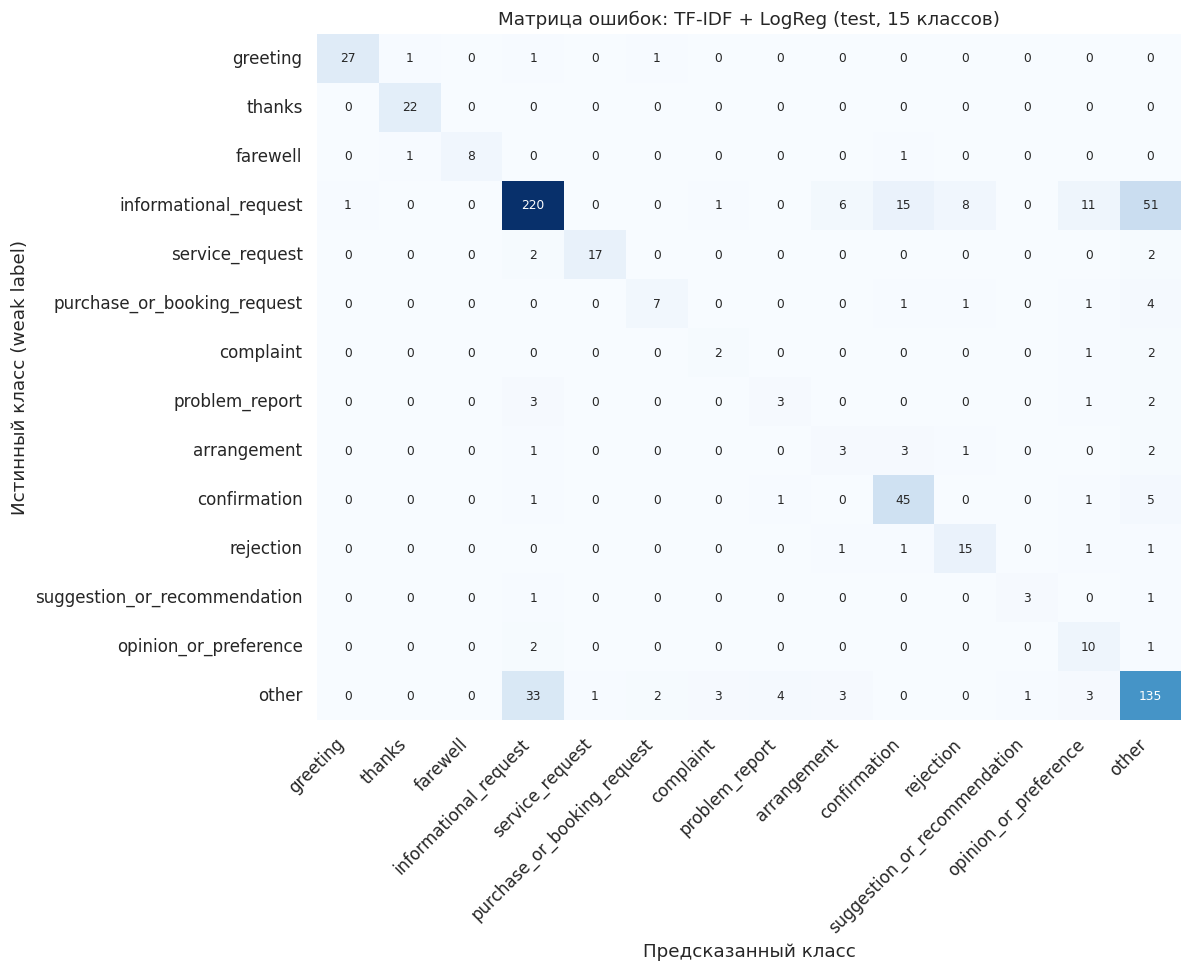

Сохранено: /content/drive/MyDrive/russian-dialogue-intent-thesis/results/figures/dialogsum_ru_intent_confusion_matrix_tfidf.png


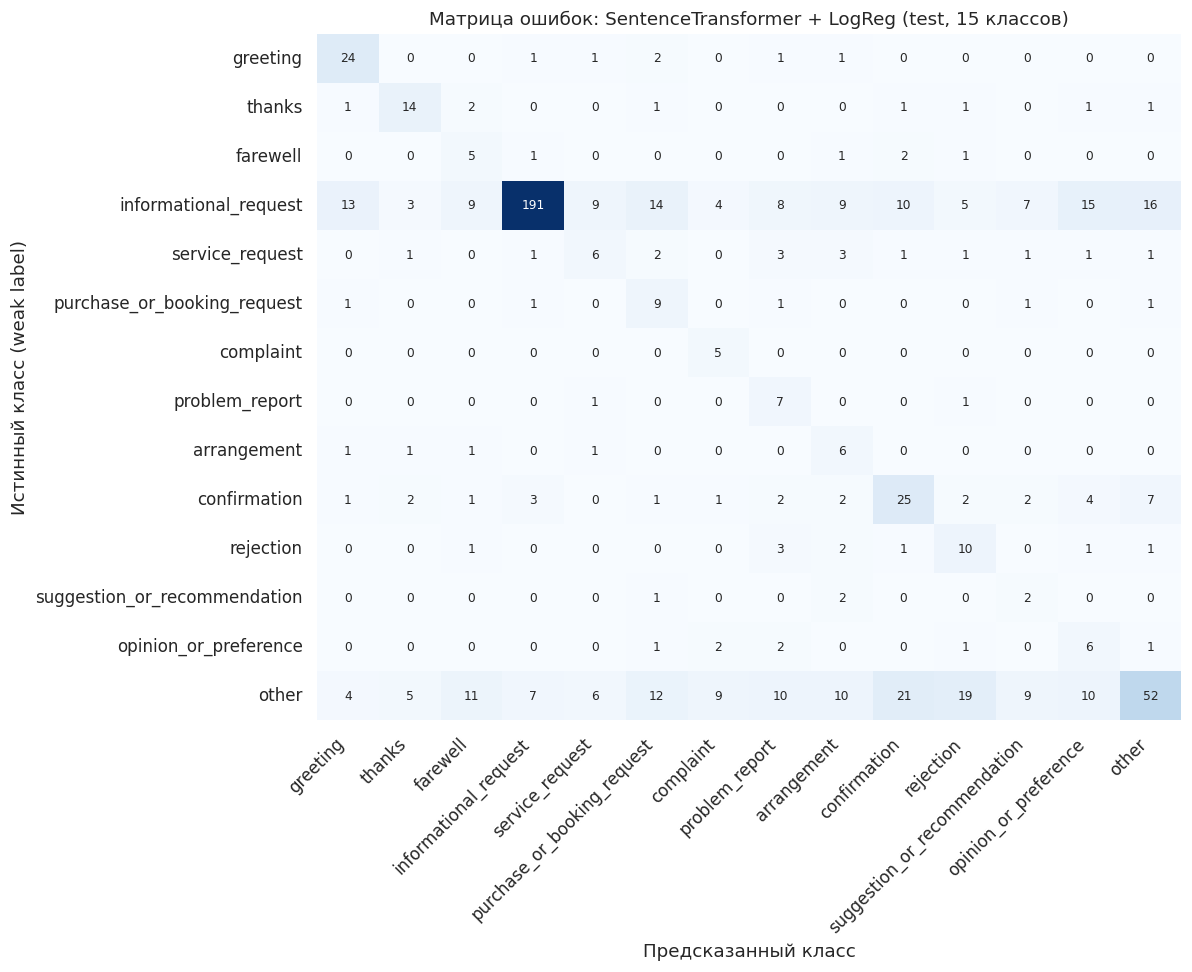

Сохранено: /content/drive/MyDrive/russian-dialogue-intent-thesis/results/figures/dialogsum_ru_intent_confusion_matrix_emb.png


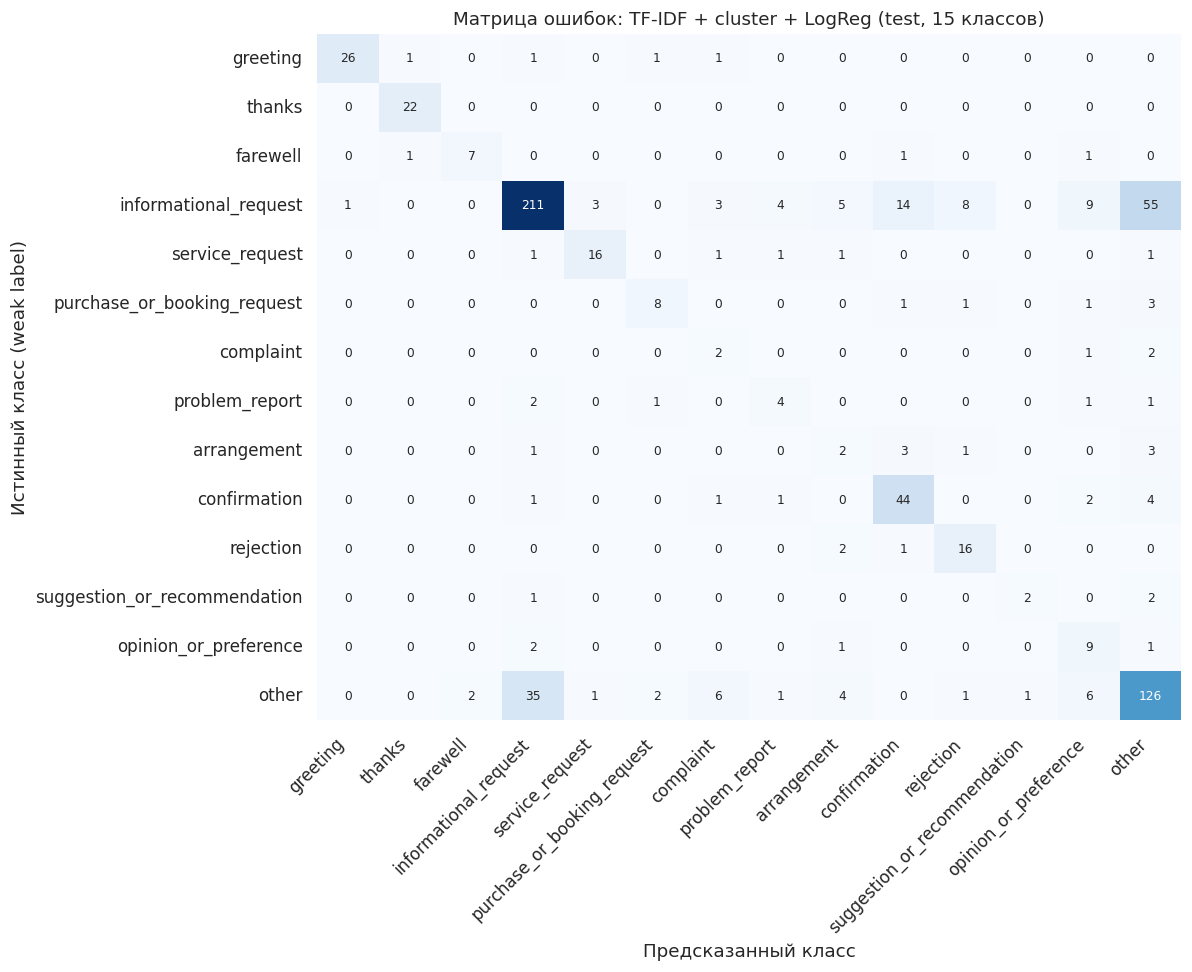

Сохранено: /content/drive/MyDrive/russian-dialogue-intent-thesis/results/figures/dialogsum_ru_intent_confusion_matrix_tfidf_cluster.png


In [15]:
# cell 15: confusion matrices
def plot_cm(y_true, y_pred, labels, title, save_path):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(11, 9))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
        cbar=False,
        annot_kws={'size': 8},
    )
    ax.set_xlabel('Предсказанный класс')
    ax.set_ylabel('Истинный класс (weak label)')
    ax.set_title(title)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    print(f'Сохранено: {save_path}')


# Стабильный порядок меток: каноническая последовательность 15 классов,
# отфильтрованная по тем, что реально встречаются в test/предсказаниях.
present = (
    set(test_df['intent_label']) | set(pred_test_tfidf)
    | set(pred_test_emb) | set(pred_test_ctx)
)
labels_present = [c for c in INTENT_ORDER if c in present]

plot_cm(
    test_df['intent_label'].values, pred_test_tfidf, labels_present,
    'Матрица ошибок: TF-IDF + LogReg (test, 15 классов)',
    os.path.join(FIGURES_DIR, 'dialogsum_ru_intent_confusion_matrix_tfidf.png'),
)
plot_cm(
    test_df['intent_label'].values, pred_test_emb, labels_present,
    'Матрица ошибок: SentenceTransformer + LogReg (test, 15 классов)',
    os.path.join(FIGURES_DIR, 'dialogsum_ru_intent_confusion_matrix_emb.png'),
)
plot_cm(
    test_df['intent_label'].values, pred_test_ctx, labels_present,
    'Матрица ошибок: TF-IDF + cluster + LogReg (test, 15 классов)',
    os.path.join(FIGURES_DIR, 'dialogsum_ru_intent_confusion_matrix_tfidf_cluster.png'),
)


## Ячейка 16 — Анализ ошибок

Смотрим, на каких репликах baseline-модель эмбеддингов ошибается. Анализируем пересечение «истинной» (слабой) метки и предсказанной, а также **тематический кластер** и `topic`, в которых ошибка произошла — это даёт интерпретируемый разрез ошибок.

In [16]:
# cell 16: анализ ошибок
err_df = pred_df[pred_df['true_label'] != pred_df['pred_emb_logreg']].copy()
print(f'Ошибок модели B (emb_logreg) на тесте: {len(err_df)} из {len(pred_df)}')

show_cols = ['utterance_text', 'true_label', 'pred_emb_logreg', 'cluster_name']
print('\nПримеры ошибок:')
print(err_df[show_cols].head(15).to_string(index=False))

print('\nТоп классов «истина -> предсказание»:')
err_pairs = err_df.groupby(['true_label', 'pred_emb_logreg']).size().sort_values(ascending=False)
print(err_pairs.head(15))

print('\nКластеры с наибольшим числом ошибок:')
print(err_df['cluster_name'].value_counts().head(10))


Ошибок модели B (emb_logreg) на тесте: 347 из 709

Примеры ошибок:
                                                                                                                                                                                                                                                                                                                       utterance_text                   true_label             pred_emb_logreg             cluster_name
                                                                                                                                                                                                                                                                        Простите, сэр. Я не могу прерывать ее. Уверен, она ненадолго.                        other                    farewell      Дом и его состояние
                                                                                                                     

## Ячейка 17 — Обсуждение: как тематический контекст помогает интенту

- **Два независимых уровня.** Намерение реплики (15 классов utterance-level) и тематический кластер диалога (домен из блокнота 08) — это **разные оси**. Кластер отвечает на вопрос «о чём идёт разговор», намерение — «что именно делает говорящий в реплике». Их комбинация `(cluster_name, intent_label)` даёт богатую, человекочитаемую интерпретацию: «жалоба в домене техподдержки», «бронирование в домене ресторана».
- **Сужение пространства намерений.** Внутри одного кластера распределение намерений сильно отличается от общего: в «жалобах на технику» априорно выше `complaint` и `problem_report`, в «расписании встреч» — `arrangement` и `confirmation`, в «магазине» — `purchase_or_booking_request`. Это даёт сильный приор для классификатора.
- **Робастность.** TF-IDF и эмбеддинги моделируют локальную форму реплики; тематический кластер моделирует **домен диалога**. Эти сигналы дополнительны: даже простая конкатенация признаков (модель C) обычно не хуже базового TF-IDF, а на доменно-зависимых классах (`service_request`, `purchase_or_booking_request`, `problem_report`) может давать прирост.
- **Перспектива.** Естественное развитие — учить совместную модель `(topic_cluster, intent)`, использовать кластер как hard-prior через class-prior, либо обучать иерархический классификатор: сначала кластер, затем условно — намерение.


## Ячейка 18 — Итоговые выводы

## Выводы

В этом ноутбуке была поставлена задача распознавания намерений на уровне отдельных реплик в DialogSum-RU. В качестве контекстного уровня использовались тематические кластеры, полученные ранее в ноутбуке `08_topic_modeling_dialogsum_ru.ipynb`: `cluster_id`, `cluster_name`, `cluster_description`, а также вероятности и оценки выбросов HDBSCAN.

Исходная таблица с результатами тематического моделирования содержит 14 460 диалогов из трёх сплитов: `train`, `validation` и `test`. Для эксперимента были выбраны 10 крупнейших не-шумовых тематических кластеров, после чего из них была построена выборка из 1 000 диалогов и 4 738 реплик. После удаления слишком редкого класса `clarification_request`, в котором было меньше 20 примеров, итоговая weak-labeled выборка составила 4 722 реплики и 14 классов намерений.

Разметка интентов в этом ноутбуке является слабой автоматической разметкой, основанной на правилах и лексических триггерах. Поэтому результаты моделей нужно интерпретировать не как качество полноценной ручной intent-разметки, а как проверку работоспособности пайплайна: разбиение диалогов на реплики, построение схемы интентов, обучение baseline-моделей и анализ ошибок.

Основной особенностью выборки оказался сильный дисбаланс классов. Наиболее частотные классы — `informational_request` и `other`: вместе они занимают большую часть корпуса. Значительно меньше представлены классы вроде `complaint`, `problem_report`, `arrangement`, `suggestion_or_recommendation` и `opinion_or_preference`. Это влияет на macro-F1: модель может показывать хорошую accuracy за счёт крупных классов, но хуже работать на редких намерениях.

Лучший результат среди baseline-моделей показала модель `TF-IDF + Logistic Regression`. На тестовой выборке она достигла accuracy около 0.73 и macro-F1 около 0.66. Это ожидаемо, потому что слабая разметка была построена по лексическим правилам, а TF-IDF хорошо улавливает такие поверхностные признаки: вопросительные слова, фразы просьбы, благодарности, отказы, жалобы и другие маркеры интентов.

Модель на sentence-эмбеддингах показала более слабый результат: accuracy около 0.51 и macro-F1 около 0.38. Это не означает, что эмбеддинги хуже для настоящей задачи intent detection. Скорее, в данном эксперименте они хуже воспроизводят rule-based разметку, потому что правила завязаны на конкретные слова и выражения, а плотные эмбеддинги сглаживают лексические различия и больше отражают общий смысл реплики.

Контекстная модель `TF-IDF + cluster_id` также не улучшила качество относительно обычного TF-IDF: тестовая accuracy около 0.70 и macro-F1 около 0.61. В текущей постановке тематический кластер не дал прироста метрик, вероятно, из-за того, что интент определяется в первую очередь локальной формой реплики, а не общей темой диалога. Однако тематические кластеры всё равно полезны для интерпретации: комбинация `topic cluster + intent` позволяет понять не только тип действия говорящего, но и предметную область, в которой это действие происходит.

Лучше всего классифицируются явно выраженные классы с устойчивыми лексическими маркерами: `greeting`, `thanks`, `farewell`, `confirmation`, `service_request`, `informational_request`. Хуже различаются более смысловые и контекстно-зависимые классы: `problem_report`, `complaint`, `arrangement`, `opinion_or_preference`, `suggestion_or_recommendation`. Для них одной реплики часто недостаточно: нужна история диалога, предыдущая реплика собеседника или более точная ручная разметка.

Анализ ошибок показывает, что модель часто путает `other` с более конкретными интентами, а также смешивает близкие классы: информационный запрос, просьбу о действии, покупку/бронирование и договорённость. Это логично, потому что в реальных диалогах одна и та же фраза может одновременно выражать запрос информации и подготовку к действию, например: “Моя машина уже готова?” или “Можно записаться на приём?”.

Таким образом, тематическое моделирование из ноутбука 08 можно использовать как дополнительный контекстный слой, но не как замену intent-разметке. Наиболее практичная схема для дальнейшей работы: использовать `cluster_id` и `cluster_name` для доменной интерпретации, а интент-модель обучать на более качественной разметке реплик. В финальной системе результат можно представлять как пару: тематический кластер диалога плюс намерение конкретной реплики.

Для дальнейшего развития эксперимента рекомендуется:

- расширить и вручную проверить разметку интентов хотя бы на части корпуса;
- объединить слишком редкие или плохо различимые классы;
- добавить контекст предыдущих реплик при классификации интента;
- сравнить модели на ручной разметке, а не только на weak labels;
- попробовать мультиязычные Transformer-модели для классификации, например RuBERT, XLM-R или multilingual MiniLM;
- отдельно оценивать качество внутри тематических кластеров, потому что разные домены могут требовать разных наборов интентов;
- использовать финальную разметку `cluster_id + intent_label` как основу для downstream-задач: анализа пользовательских запросов, построения сценариев диалогов и подготовки обучающих данных для intent recognition.

Итог: текущий ноутбук успешно строит воспроизводимый baseline для intent detection на DialogSum-RU. Лучшей baseline-моделью в данной weak-label постановке является `TF-IDF + Logistic Regression`, а тематические кластеры из ноутбука 08 оказываются наиболее полезными не для прямого улучшения метрик, а для интерпретируемости и доменной структуризации интентов.